# Bell State Preparation experiment: Compute $\langle \bar{\Phi}^+ | \bar{Z}\bar{Z} | \bar{\Phi}^+\rangle$ with the seven-qubit Steane code

In [1]:
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import cirq

import qiskit
import stimcirq

from encoded.tcc import tcc_encoding

/Users/ryan/prof/work/encoded/envencoded/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## Set parameters

In [139]:
d = 7                                   # Code distance.
nshots = 1_000_000                        # Number of samples/shots
noise_rate = 0.001
k = 2                                   # Number of logical qubits.
observable: str = "ZZ"                  # (Logical) observable to measure. Either XX or ZZ.
depths = np.arange(0, 120 + 1, 10)

In [140]:
distance_to_nqubits = lambda d: (3 * d ** 2 + 1) // 4

n = distance_to_nqubits(d)
n

37

## Run physical experiment

In [4]:
a, b = cirq.LineQubit.range(2)
circuit = cirq.Circuit(
    cirq.H.on(a),
    cirq.CNOT.on(a, b),
)
nshots_physical: int = 10_000

evals_physical = []
for depth in depths:
    print(depth)
    physical = circuit.copy()
    physical.append(cirq.X.on_each(a, b) for _ in range(depth))
    physical = physical.with_noise(cirq.depolarize(noise_rate))
    physical.append(cirq.measure(a, b, key="z"))
    results = cirq.Simulator().run(physical, repetitions=nshots_physical)
    bins = results.histogram(key="z")
    eval = bins.get(0, 0) - bins.get(1, 0) - bins.get(2, 0) + bins.get(3, 0)
    eval /= nshots_physical
    evals_physical.append(eval)

0


KeyboardInterrupt: 

## Run encoded experiment

### Compute/load 0_L / 1_L bitstrings

In [5]:
try:
    zero_bitstrings = np.loadtxt(f"zero_bitstrings_d{d}.txt")
    print("Loaded zero bitstrings (ints) from memory:", zero_bitstrings)
except FileNotFoundError:
    print(f"Unable to load zero bitstrings for distance {d} from memory, computing them...")
    encode_circuit = tcc_encoding(d)
    encode_circuit = cirq.H.on_each(encode_circuit.all_qubits()) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.
    s = stimcirq.cirq_circuit_to_stim_circuit(encode_circuit + cirq.measure(encode_circuit.all_qubits())).compile_sampler()
    zero_bitstrings = sorted(set([int.from_bytes(bytes(b), 'little') for b in s.sample(20_000_000, bit_packed=True)]))
    print("Computed these bitstrings (ints) and saved to memory:", zero_bitstrings)
    np.savetxt(f"zero_bitstrings_d{d}.txt", zero_bitstrings)

try:
    one_bitstrings = np.loadtxt(f"one_bitstrings_d{d}.txt")
    print("Loaded one bitstrings (ints) from memory:", one_bitstrings)
except FileNotFoundError:
    print(f"Unable to load one bitstrings for distance {d} from memory, computing them...")
    encode_circuit = tcc_encoding(d)
    encode_circuit = cirq.H.on_each(encode_circuit.all_qubits()) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.
    encode_circuit.append(cirq.X.on_each(encode_circuit.all_qubits()))  # Put into 1_L state.
    s = stimcirq.cirq_circuit_to_stim_circuit(encode_circuit + cirq.measure(encode_circuit.all_qubits())).compile_sampler()
    one_bitstrings = sorted(set([int.from_bytes(bytes(b), 'little') for b in s.sample(20_000_000, bit_packed=True)]))
    print("Computed these bitstrings (ints) and saved to memory:", one_bitstrings)
    np.savetxt(f"one_bitstrings_d{d}.txt", one_bitstrings)

Loaded zero bitstrings (ints) from memory: [0.00000000e+00 1.50000000e+01 5.40000000e+01 ... 1.36364671e+11
 1.36364671e+11 1.36364671e+11]
Loaded one bitstrings (ints) from memory: [1.07428264e+09 1.07428265e+09 1.07428266e+09 ... 1.37438953e+11
 1.37438953e+11 1.37438953e+11]


In [6]:
encode_circuit = tcc_encoding(d)
qubits = sorted(encode_circuit.all_qubits())
encode_circuit = cirq.H.on_each(qubits) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.

qreg = cirq.LineQubit.range(n * k)
encoding = cirq.Circuit.concat_ragged(
    encode_circuit,
    encode_circuit.transform_qubits({a: b for a, b in zip(qreg[:n], qreg[n:])})
)
encoding.append(cirq.X.on_each(qreg[:n]))

# Prepare Bell state
encoding.append(cirq.Moment(cirq.H.on_each(qreg[:n])))
encoding.append(cirq.CNOT.on_each([(qreg[i], qreg[i+n]) for i in range(n)]))
encoding

┌──┐                                       ┌──┐                               ┌──┐                               ┌──┐                           ┌──┐                                   ┌──┐                                           ┌──┐                                   ┌──┐                       ┌──┐                       ┌──┐                                   ┌──┐                   ┌──┐       ┌──┐               ┌──┐   ┌──┐                       ┌──┐   ┌──┐   ┌──┐   ┌──┐   ┌──┐                   ┌──┐                                       ┌─────────────────────────────────────┐
0: ────H───@───@───@───@───@───@───@───@────@─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────Y───H───X───H────@────────────────────────────────────────
           │   │   │   │   │   │   │   │    │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              │
1: ────H───┼───┼───┼───┼───┼───┼───┼───┼────┼@────@───@───@───@───@───@───@───@───@────@──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────H───X───H────┼@───────────────────────────────────────
           │   │   │   │   │   │   │   │    ││    │   │   │   │   │   │   │   │   │    │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   ││
2: ────H───┼───┼───┼───┼───┼───┼───┼───┼────┼┼────┼───┼───┼───┼───┼───┼───┼───┼───┼────┼@────@───@───@───@───@───@───@────@───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────H───X───H────┼┼@──────────────────────────────────────
           │   │   │   │   │   │   │   │    ││    │   │   │   │   │   │   │   │   │    ││    │   │   │   │   │   │   │    │                                                                                                                                                                                                                                    

### One-time pass: Embed to heavy hex then simulate with noise

In [7]:
import qiskit_ibm_runtime


service = qiskit_ibm_runtime.QiskitRuntimeService(
    channel="ibm_cloud",
    token="Vwp-noJ99qjdtslYdRY6aEClfwr6PM63bP1Az7fE3015",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/8adb079e32e34c679acff94b68640033:f54da97d-7fe5-4108-9409-98a68f6ca53f::",
)
computer = service.backend("ibm_boston")
layout = {
    7: list(range(27, 35 + 1)) + [38, 39] + list(range(47, 55 + 1)) + [57, 58, 59] + list(range(66, 75 + 1)) + [78, 79] + list(range(86, 95 + 1)) + [97, 98, 99] + list(range(104, 115 + 1)) + [117, 118, 119] + list(range(124, 134 + 1))
}

qiskit_runtime_service._discover_account:WARNING:2026-04-26 17:25:13,248: Loading account with the given token. A saved account will not be used.


In [8]:
type(computer)

qiskit_ibm_runtime.ibm_backend.IBMBackend

In [19]:
computer.coupling_map.graph.edge_list()

EdgeList[(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), (7, 6), (7, 8), (7, 17), (8, 7), (8, 9), (9, 8), (9, 10), (10, 9), (10, 11), (11, 10), (11, 12), (11, 18), (12, 11), (12, 13), (13, 12), (13, 14), (14, 13), (14, 15), (15, 14), (15, 19), (16, 3), (16, 23), (17, 7), (17, 27), (18, 11), (18, 31), (19, 15), (19, 35), (20, 21), (21, 20), (21, 22), (21, 36), (22, 21), (22, 23), (23, 16), (23, 22), (23, 24), (24, 23), (24, 25), (25, 24), (25, 26), (25, 37), (26, 25), (26, 27), (27, 17), (27, 26), (27, 28), (28, 27), (28, 29), (29, 28), (29, 30), (29, 38), (30, 29), (30, 31), (31, 18), (31, 30), (31, 32), (32, 31), (32, 33), (33, 32), (33, 34), (33, 39), (34, 33), (34, 35), (35, 19), (35, 34), (36, 21), (36, 41), (37, 25), (37, 45), (38, 29), (38, 49), (39, 33), (39, 53), (40, 41), (41, 36), (41, 40), (41, 42), (42, 41), (42, 43), (43, 42), (43, 44), (43, 56), (44, 43), (44, 45), (45, 37), (45, 44), (45, 46), (46, 45), (46

In [57]:
import networkx as nx

In [126]:
g = nx.Graph()

for a, b in computer.coupling_map.graph.edge_list():
    g.add_edge(cirq.LineQubit(a), cirq.LineQubit(b))

g = g.subgraph([cirq.LineQubit(q) for q in layout[d]])

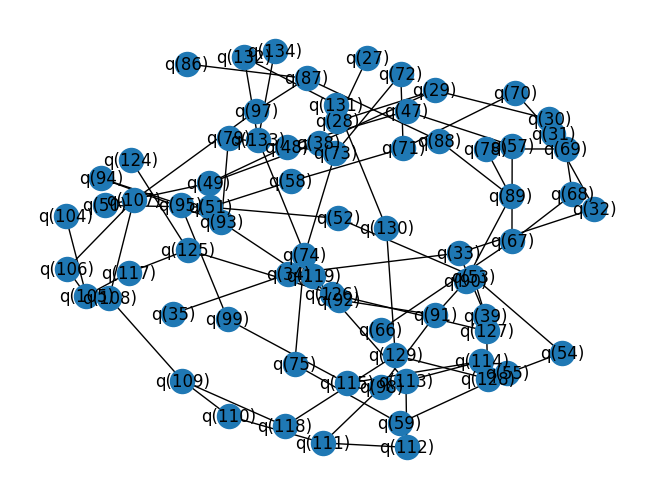

In [127]:
nx.draw(g, pos=nx.spring_layout(g, k=0.5, weight="weight"), with_labels=True)

In [129]:
for a, b in g.edges():
    print(a, b)

q(128) q(127)
q(128) q(129)
q(129) q(118)
q(129) q(130)
q(130) q(131)
q(131) q(132)
q(132) q(133)
q(133) q(119)
q(133) q(134)
q(27) q(28)
q(28) q(29)
q(29) q(30)
q(29) q(38)
q(30) q(31)
q(31) q(32)
q(32) q(33)
q(33) q(34)
q(33) q(39)
q(34) q(35)
q(38) q(49)
q(39) q(53)
q(47) q(48)
q(47) q(57)
q(48) q(49)
q(49) q(50)
q(50) q(51)
q(51) q(52)
q(51) q(58)
q(52) q(53)
q(53) q(54)
q(54) q(55)
q(55) q(59)
q(57) q(67)
q(58) q(71)
q(59) q(75)
q(66) q(67)
q(67) q(68)
q(68) q(69)
q(69) q(70)
q(69) q(78)
q(70) q(71)
q(71) q(72)
q(72) q(73)
q(73) q(74)
q(73) q(79)
q(74) q(75)
q(78) q(89)
q(79) q(93)
q(86) q(87)
q(87) q(88)
q(87) q(97)
q(88) q(89)
q(89) q(90)
q(90) q(91)
q(91) q(92)
q(91) q(98)
q(92) q(93)
q(93) q(94)
q(94) q(95)
q(95) q(99)
q(97) q(107)
q(98) q(111)
q(99) q(115)
q(104) q(105)
q(105) q(106)
q(105) q(117)
q(106) q(107)
q(107) q(108)
q(108) q(109)
q(109) q(110)
q(109) q(118)
q(110) q(111)
q(111) q(112)
q(112) q(113)
q(113) q(114)
q(113) q(119)
q(114) q(115)
q(117) q(125)
q(124) q(125)

In [20]:
class HeavyHex(cirq.CompilationTargetGateset):
    def __init__(self) -> None:
        super().__init__(
            cirq.AnyIntegerPowerGateFamily(cirq.XPowGate),
            cirq.AnyIntegerPowerGateFamily(cirq.ZPowGate),
            cirq.AnyIntegerPowerGateFamily(cirq.YPowGate),
            [cirq.CZPowGate.on(a, b) for a, b in computer.coupling_map.graph.edge_list()]
        )

In [123]:
graph = cirq.contrib.graph_device.UndirectedHypergraph()

In [124]:
cirq.contrib.graph_device.is_undirected_device_graph(graph)

True

In [130]:
for edge in g.edges():
    graph.add_edge(edge)

In [131]:
cirq.contrib.graph_device.is_undirected_device_graph(graph)

True

In [132]:
device = cirq.contrib.graph_device.graph_device.UndirectedGraphDevice(device_graph=graph)

In [ ]:
cirq.optimize_for_target_gateset()

In [74]:
q = qiskit.QuantumCircuit.from_qasm_str(encoding.to_qasm())

to_run = q.copy()
to_run.barrier()

# Idle time/X gates.
for _ in range(depth):
    to_run.x(to_run.qubits)
    to_run.barrier()
    to_run.x(to_run.qubits)
    to_run.barrier()

if observable == "XX":
    to_run.h(to_run.qubits)
to_run.count_ops()

OrderedDict([('x', 17813),
             ('cz', 284),
             ('barrier', 241),
             ('h', 149),
             ('cx', 37),
             ('y', 24),
             ('z', 12)])

In [ ]:
to_run = qiskit.transpile(
    to_run, 
    backend=computer,
    initial_layout=layout[d],
    routing_method="sabre",
    # scheduling_method="asap",
    optimization_level=3,
)
to_run.count_ops()

qiskit_runtime_service._discover_account:WARNING:2026-04-26 17:20:03,340: Loading account with the given token. A saved account will not be used.


OrderedDict([('x', 17980),
             ('sx', 6048),
             ('cz', 3237),
             ('rz', 2568),
             ('barrier', 241)])

In [76]:
to_run = qiskit.transpile(
    to_run,
    basis_gates=['h', 's', 'cx', 'x', 'y', 'z', 'id'],
)

TranspilerError: 'Unable to translate the operations in the circuit: {("sx", 1), ("rz", 1), ("cz", 2), ("x", 1), ("barrier", 74)} to the backend\'s (or manually specified) target basis: {"h", "id", "if_else", "for_loop", "delay", "cx", "box", "switch_case", "measure", "s", "x", "while_loop", "y", "reset", "z", "barrier", "snapshot", "store"}. This likely means the target basis is not universal or there are additional equivalence rules needed in the EquivalenceLibrary being used. For more details on this error see: https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.transpiler.passes.BasisTranslator#translation-errors'

In [63]:
from qiskit.transpiler.passes import RemoveBarriers

In [59]:
from cirq.contrib.qasm_import import circuit_from_qasm

In [60]:
from qiskit import qasm2

In [67]:
c = circuit_from_qasm(qasm2.dumps(RemoveBarriers()(to_run)))

In [68]:
len(list(c.all_operations()))

29783

In [69]:
noisy_embedded = c.with_noise(cirq.depolarize(noise_rate))

In [70]:
noisy_embedded += cirq.measure(noisy_embedded.all_qubits(), key="z")

In [71]:
sampler = stimcirq.cirq_circuit_to_stim_circuit(noisy_embedded).compile_sampler()

TypeError: Don't know how to translate cirq.Rz(rads=1.5707963267948966).on(cirq.NamedQubit('q_27')) into stim gates.
- It doesn't have a _decompose_ method that returns stim-compatible operations.
- It doesn't have a _stim_conversion_ method.


### Classical simulation

In [7]:
evals = []
ncodewords = []
postselection_rates = []
stds = []
for depth in depths:
    print("Status: On depth", depth)
    to_run = encoding.copy()
    to_run.append(
        cirq.X.on_each(to_run.all_qubits()) for _ in range(depth)
    )
    noisy = to_run.with_noise(cirq.depolarize(noise_rate))
    noisy += cirq.measure(noisy.all_qubits(), key="z")

    sampler = stimcirq.cirq_circuit_to_stim_circuit(noisy).compile_sampler()
    results = sampler.sample(shots=nshots)
    results = results.T[::-1].T

    all_counts = [qiskit.primitives.BitArray.from_bool_array(results).get_counts()]

    expval: float = 0.0
    num_noncodewords = 0
    num00 = 0
    num01 = 0
    num10 = 0
    num11 = 0
    for bitstring, count in all_counts[0].items():
        q0 = int("".join(str(s) for s in bitstring[:n][::]), 2)  # NOTE: Endianess.
        q1 = int("".join(str(s) for s in bitstring[n:][::]), 2)  # NOTE: Endianess.
        if q0 in zero_bitstrings and q1 in zero_bitstrings:
            expval += count
            num00 += count
        elif q0 in zero_bitstrings and q1 in one_bitstrings:
            expval -= count
            num01 += count
        elif q0 in one_bitstrings and q1 in zero_bitstrings:
            expval -= count
            num10 += count
        elif q0 in one_bitstrings and q1 in one_bitstrings:
            expval += count
            num11 += count
        else:
            num_noncodewords += count

    num_codewords = nshots - num_noncodewords
    std_estimate = 1.0 / num_codewords
    postselection_rate = num_codewords / nshots
    expval /= num_codewords

    evals.append(expval)
    ncodewords.append(num_codewords)
    postselection_rates.append(postselection_rate)
    stds.append(std_estimate)

Status: On depth 0
Status: On depth 10
Status: On depth 20
Status: On depth 30
Status: On depth 40
Status: On depth 50
Status: On depth 60
Status: On depth 70
Status: On depth 80
Status: On depth 90
Status: On depth 100
Status: On depth 110
Status: On depth 120


In [8]:
evals = np.array(evals)
ncodewords = np.array(ncodewords)
postselection_rates = np.array(postselection_rates)
stds = np.array(stds)

In [41]:
fname = f"tcc_sim_depolarizing_{noise_rate}_distance_{d}_maxdepth_{max(depths)}_with_physical"
fname

'tcc_sim_depolarizing_0.001_distance_7_maxdepth_120_with_physical'

In [ ]:
# depths_physical = np.arange(0, 80 + 1, 10)
# evals_physical = [0.8928, 0.8486, 0.7888, 0.71, 0.6816, 0.7142, 0.1396, -0.3554, -0.6212]  # Hardware physical evals.

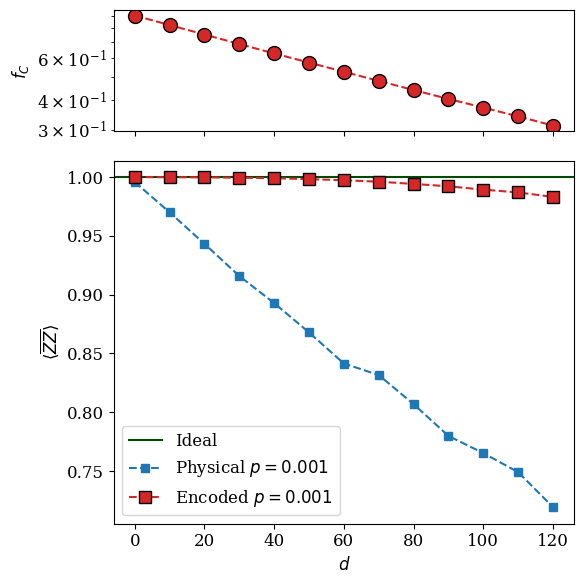

In [42]:
alpha_fill = 0.55

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [0.3334, 1]},
    figsize=(6, 6)
)

ax_bottom.axhline(y=1.0, color="xkcd:darkgreen", label="Ideal")
ax_bottom.plot(depths, evals_physical, "--s", color="tab:blue", label=f"Physical $p = {noise_rate}$")
ax_bottom.plot(depths, evals, "--s", ms=8, color="tab:red", mec="black", label=f"Encoded $p = {noise_rate}$")
ax_bottom.fill_between(
    depths,
    [max(-1, x) for x in evals - stds],
    [min(1, x) for x in evals + stds],
    alpha=alpha_fill
)


ax_bottom.set_xlabel("$d$")
ax_bottom.set_ylabel(r"$\langle \overline{ZZ} \rangle$")
ax_bottom.legend()

ax_top.semilogy(depths, postselection_rates, "--o", mec="black", ms=10,
            color="tab:red", label=f"Encoded $p = {noise_rate}$")

ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("$f_C$")
# ax_top.legend()

plt.tight_layout()
plt.savefig(f"{fname}.pdf");

In [12]:
np.savetxt(fname + "_evals.txt", evals)
np.savetxt(fname + "_ncodewords.txt", ncodewords)
np.savetxt(fname + "_postselectionrates.txt", postselection_rates)
np.savetxt(fname + "_stds.txt", stds)

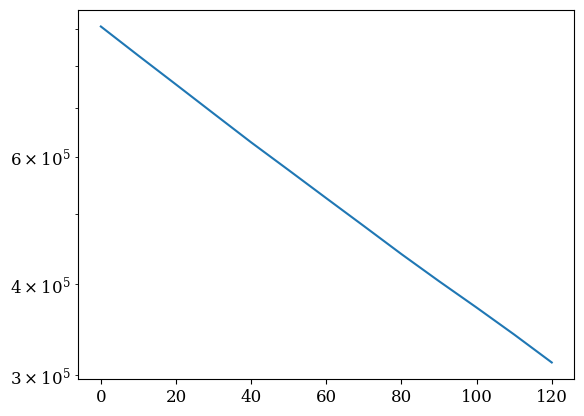

In [13]:
plt.semilogy(depths, ncodewords)

In [ ]:
# logical_state_labels = [r"$\overline{0}\overline{0}$", r"$\overline{0}\overline{1}$", r"$\overline{1}\overline{0}$", r"$\overline{1}\overline{1}$"]
# plt.bar(
#     logical_state_labels,
#     [num00, num01, num10, num11],
# )

In [ ]:
expval / num_codewords